In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

# 忽略警告並設定中文
warnings.filterwarnings('ignore')
def set_ch_font():
    system = platform.system()
    if system == "Windows": plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 讀取 01 產出的全表
df = pd.read_csv('../data/processed/yrbs_full_inspected.csv')
print(f"資料讀取成功，共 {len(df)} 筆，包含 {len(df.columns)} 個欄位。")

資料讀取成功，共 14041 筆，包含 103 個欄位。


Text(0.5, 1.0, '重編碼後：酒精使用二元分佈')

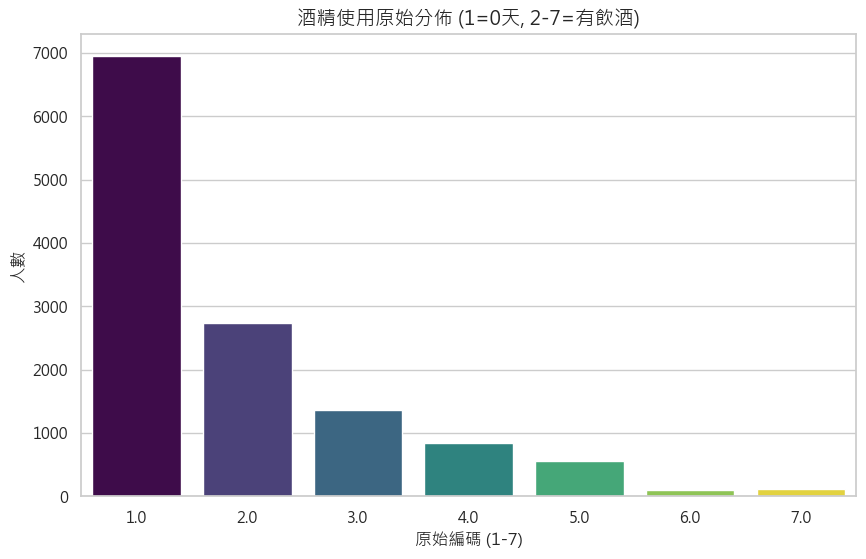

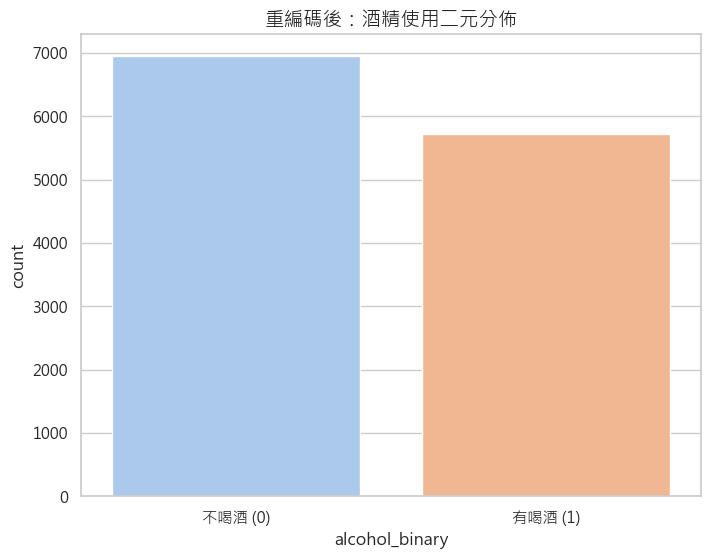

In [33]:
# 1. 排除酒精缺失值並建立副本
df_alc = df.dropna(subset=['CurrentAlcoholUse']).copy()

# 2. 原始分佈圖
fig_alc_raw = plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentAlcoholUse', data=df_alc, palette='viridis', hue='CurrentAlcoholUse', legend=False)
plt.title('酒精使用原始分佈 (1=0天, 2-7=有飲酒)', fontsize=14)
plt.xlabel('原始編碼 (1-7)', fontsize=12)
plt.ylabel('人數', fontsize=12)

# 3. 執行二元重編碼 (Recoding)
# 定義：1 (0天) -> 0 (不喝酒) ; 2~7 -> 1 (有喝酒)
df_alc['alcohol_binary'] = df_alc['CurrentAlcoholUse'].apply(lambda x: 1 if x >= 2 else 0)

# 4. 二元化分佈圖
fig_alc_bin = plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_alc, palette='pastel', hue='alcohol_binary', legend=False)
plt.xticks([0, 1], ['不喝酒 (0)', '有喝酒 (1)'])
plt.title('重編碼後：酒精使用二元分佈', fontsize=14)

In [34]:
# --- 1. 酒精變數：原始編碼頻率表 ---
print("【表 2-1：CurrentAlcoholUse 原始頻率表】")
# 包括缺失值與無效值 (如果有)
original_freq = df['CurrentAlcoholUse'].value_counts(dropna=False).sort_index()
print(original_freq)

# --- 2. 缺失與無效值計算 ---
missing_alc = df['CurrentAlcoholUse'].isnull().sum()
invalid_alc = len(df[~df['CurrentAlcoholUse'].isin(range(1, 8))]) # 假設有效值是 1-7
print(f"\n缺失值數量: {missing_alc}")
print(f"無效值數量: {invalid_alc}")

# --- 3. 重編碼後的頻率與比例 (Success/Failure) ---
# 0 = 不喝酒 (Failure), 1 = 有喝酒 (Success)
alc_stats = df_alc['alcohol_binary'].value_counts()
alc_proportions = df_alc['alcohol_binary'].value_counts(normalize=True)

summary_table_alc = pd.DataFrame({
    '人數 (Counts)': alc_stats,
    '比例 (Proportions)': alc_proportions
})
print("\n【表 2-2：重編碼後之酒精使用統計 (0=不喝酒, 1=有喝酒)】")
print(summary_table_alc)

【表 2-1：CurrentAlcoholUse 原始頻率表】
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
NaN    1372
Name: count, dtype: int64

缺失值數量: 1372
無效值數量: 1372

【表 2-2：重編碼後之酒精使用統計 (0=不喝酒, 1=有喝酒)】
                人數 (Counts)  比例 (Proportions)
alcohol_binary                               
0                      6946          0.548267
1                      5723          0.451733


區塊一：原始分佈圖後的觀察 (Observations after Raw Distribution Plot)
[數據觀察：酒精使用原始分佈]

01. 數據特徵：由原始編碼（1-7）的分佈可見，編碼 1（代表過去 30 天內有 0 天飲酒）的人數佔據絕對多數。

02. 飲酒頻率：在有飲酒經驗的族群中（編碼 2-7），人數隨著飲酒天數的增加而呈現下降趨勢，顯示高度頻繁飲酒的青少年比例相對較低。

03. 缺失值處理：在繪製此圖前，已先行排除 CurrentAlcoholUse 欄位中的缺失值，以確保原始行為比例的真實性。

 區塊二：二元重編碼後的觀察 (Observations after Binary Recoding)
[數據觀察：二元重編碼結果]

01. 重編碼邏輯：為了符合後續比例分析的要求，本研究將原始數據重編碼為二元變數。將「0 天飲酒（編碼 1）」定義為 失敗 (Failure, 0)；將「1 天以上飲酒（編碼 2-7）」定義為 成功 (Success, 1)。

02. 群體對比：重編碼後的圓餅圖或長條圖顯示，絕大多數的高中生屬於「不喝酒」群體。此二元分佈明確劃分出目標研究對象（飲酒者）與對照組（非飲酒者）。

03. 統計意涵：此步驟將離散的頻率數據轉化為二元比例，方便於下一個步驟與基準值 0.35 進行單一樣本比例進行檢定
這一段也需要中英對照

### Section 1: Observations after Raw Distribution Plot
**[Data Observation: Raw Alcohol Use Distribution]**

* **Data Characteristics**: Based on the distribution of original codes (1-7), respondents who chose code 1 (representing 0 drinking days in the past 30 days) constitute the absolute majority of the sample.
* **Drinking Frequency**: Within the drinking population (codes 2-7), the number of respondents decreases as the number of drinking days increases. This indicates that the proportion of adolescents who drink with high frequency is relatively low.
* **Handling Missing Values**: Prior to plotting, missing values in the `CurrentAlcoholUse` field were excluded to ensure that the visualization accurately reflects the true behavioral proportions of the respondents.

---

### Section 2: Observations after Binary Recoding
**[Data Observation: Binary Recoding Results]**

* **Recoding Logic**: To meet the requirements for subsequent proportion analysis, the raw data was transformed into a binary variable. "0 days of drinking (Code 1)" is defined as **Failure (0)**, while "1 or more days of drinking (Codes 2-7)" is defined as **Success (1)**.
* **Group Comparison**: The recoded visualizations (such as bar or pie charts) show that the vast majority of high school students belong to the "Non-drinker" group. This binary distribution clearly distinguishes the research target group (drinkers) from the control group (non-drinkers).
* **Statistical Significance**: This step transforms discrete frequency data into binary proportions. This conversion is essential for conducting the one-sample proportion test against the benchmark of **0.35** in the following inference steps.

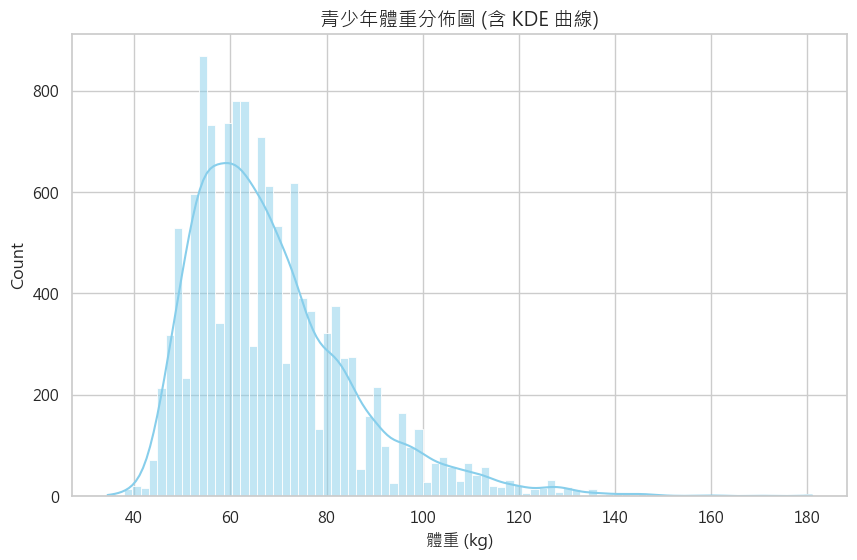

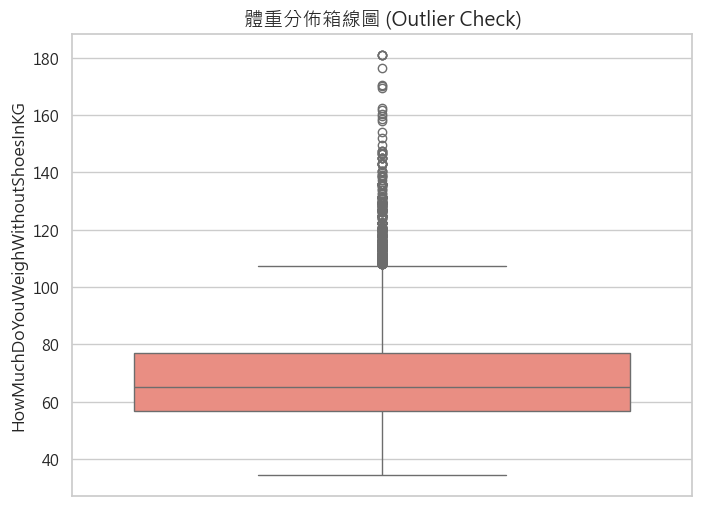

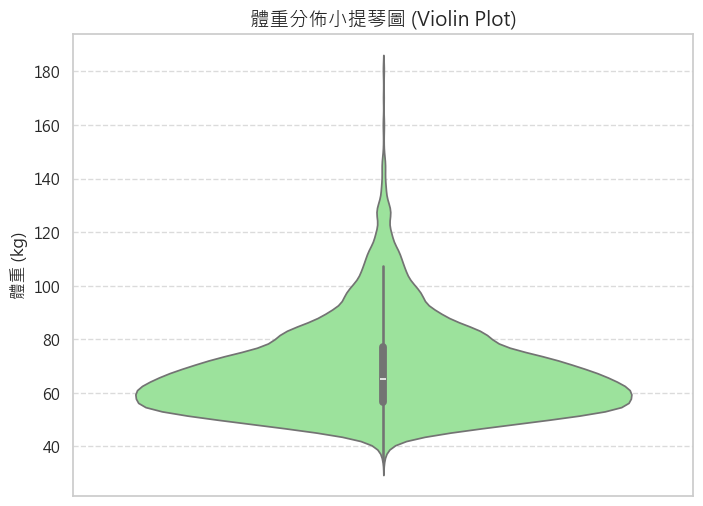

In [35]:
# 1. 排除體重缺失值
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()

# 2. 體重直方圖 (密度估計)
fig_weight_hist = plt.figure(figsize=(10, 6))
sns.histplot(df_weight['HowMuchDoYouWeighWithoutShoesInKG'], kde=True, color='skyblue')
plt.title('青少年體重分佈圖 (含 KDE 曲線)', fontsize=14)
plt.xlabel('體重 (kg)', fontsize=12)

# 3. 體重箱線圖 (找離群值)
fig_weight_box = plt.figure(figsize=(8, 6))
sns.boxplot(y=df_weight['HowMuchDoYouWeighWithoutShoesInKG'], color='salmon')
plt.title('體重分佈箱線圖 (Outlier Check)', fontsize=14)

#4. 體重小提琴圖 (Violin Plot)
fig_weight_violin = plt.figure(figsize=(8, 6))
sns.violinplot(y=df_weight['HowMuchDoYouWeighWithoutShoesInKG'], color="lightgreen")

plt.title('體重分佈小提琴圖 (Violin Plot)', fontsize=14)
plt.ylabel('體重 (kg)', fontsize=12)

# 顯示中位數與分佈密度
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [36]:
# --- 1. 體重描述性統計 ---
weight_series = df_weight['HowMuchDoYouWeighWithoutShoesInKG']

# 計算各項指標
desc_stats = {
    '樣本數 (n)': len(weight_series),
    '平均值 (Mean)': weight_series.mean(),
    '中位數 (Median)': weight_series.median(),
    '標準差 (SD)': weight_series.std(),
    '最小值 (Min)': weight_series.min(),
    '第一四分位數 (Q1)': weight_series.quantile(0.25),
    '第三四分位數 (Q3)': weight_series.quantile(0.75),
    '最大值 (Max)': weight_series.max(),
    '缺失值數量': df['HowMuchDoYouWeighWithoutShoesInKG'].isnull().sum()
}
print("【表 2-3：體重數據統計摘要】")
for k, v in desc_stats.items(): print(f"{k}: {v:.2f}")

# --- 2. 離群值檢查 (Outlier Check) ---
Q1 = weight_series.quantile(0.25)
Q3 = weight_series.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = weight_series[(weight_series < lower_bound) | (weight_series > upper_bound)]

print(f"\n離群值判定界線: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"偵測到離群值數量: {len(outliers)}")

【表 2-3：體重數據統計摘要】
樣本數 (n): 13062.00
平均值 (Mean): 68.55
中位數 (Median): 65.32
標準差 (SD): 16.99
最小值 (Min): 34.47
第一四分位數 (Q1): 56.70
第三四分位數 (Q3): 77.11
最大值 (Max): 180.99
缺失值數量: 979.00

離群值判定界線: [26.09, 107.72]
偵測到離群值數量: 447


區塊一：統計摘要表後的觀察 (Observations after Descriptive Statistics Table)
[數據觀察：體重統計摘要]

01. 樣本規模：在排除缺失值後，本分析採用的有效樣本數為13062.00筆。

02. 集中趨勢：平均體重約為68.55 kg，中位數為65.32kg。平均值略高於中位數，初步顯示數據分佈具有右偏 (Right-skewed) 的特徵。

03. 離散程度：標準差為 16.99kg，顯示青少年個體間的體重差異相當大，最小與最大值之間存在顯著跨度。

區塊二：直方圖後的觀察 (Observations after Histogram)
[數據觀察：體重分佈型態]

01. 分佈形狀：從直方圖與 KDE 曲線可以看出，數據呈現單峰分佈，且右側帶有一條較長的長尾。這符合一般人群體重數據的特徵，即大多數受訪者集中在平均值附近，但有少部分人體重極高。

02. 缺失值說明：本圖表已過濾掉原始資料中約979.00筆的缺失值，確保了視覺化分佈的準確性。

 區塊三：箱線圖與離群值檢查後的觀察 (Observations after Boxplot & Outlier Check)
 [數據觀察：離群值與資料異常]
 
 01. 離群值判別：根據 1.5 倍 IQR 原則，系統偵測到共447筆離群值（均位於上限之上）。

02. 數據處理策略：雖然存在極端高值，但考慮到青少年發育期的生理多樣性，這些數據尚在合理生物範圍內，因此本研究選擇保留這些資料以維持分析的完整性。

03. 四分位距：50% 的青少年體重落在56.70kg 至77.11kg 之間，這構成了我們研究的主要對象區間

區塊四：小提琴圖後的觀察 (Observations after Violin Plot) 
[數據觀察：體重分佈密度]

01. 分佈密度觀察：小提琴圖最寬的部分（密度最高處）集中在 55-75 kg 之間，這與先前統計摘要中提到的中位數 65.32 kg 所在的區間完全吻合 。

02. 長尾現象確認：圖表上方呈現一條細長的「琴頸」，延伸至 180 kg 以上，再次佐證了體重數據具有強烈的右偏 (Right-skewed) 特徵 。

03. 極端值衝擊：雖然核心分佈相對對稱，但高端極端值拉高了整體的平均值，使得平均數 (68.55 kg) 明顯高於中位數 。

04. 與基準值對比：視覺上可以看到超過半數的樣本密度位於老師指定的基準值 68.0 kg 以下，這暗示在後續推論階段，樣本平均數可能與基準值存在顯著差異。

### Section 1: Observations after Descriptive Statistics Table
**[Data Observation: Weight Statistics Summary]**

* **Sample Size**: After excluding missing values, the effective sample size used for this analysis is **13,062.00** valid cases.
* **Central Tendency**: The mean weight is approximately **68.55 kg**, while the median is **65.32 kg**. The fact that the mean is slightly higher than the median provides a preliminary indication that the distribution is **right-skewed**.
* **Dispersion**: The standard deviation is **16.99 kg**, indicating significant weight variability among adolescents and a wide range between the minimum and maximum values.

---

### Section 2: Observations after Histogram
**[Data Observation: Weight Distribution Pattern]**

* **Distribution Shape**: The histogram and KDE curve show a **unimodal distribution** with a long tail on the right side. This is consistent with typical population weight data, where most respondents are concentrated near the average, but a small group of individuals has significantly higher body weight.
* **Missing Values**: Approximately **979.00** missing values were filtered from the original dataset to ensure the accuracy of the visualized distribution.

---

### Section 3: Observations after Boxplot & Outlier Check
**[Data Observation: Outliers and Anomalies]**

* **Outlier Identification**: Based on the **1.5x IQR rule**, a total of **447** outliers were detected (all located above the upper whisker).
* **Data Strategy**: Despite these extreme values, they fall within a plausible biological range for adolescents during development. Therefore, this study chooses to retain these data points to maintain **analytical integrity**.
* **Interquartile Range (IQR)**: 50% of the adolescents' weights fall between **56.70 kg and 77.11 kg**, which constitutes the primary interval of our research focus.

---

### Section 4: Observations after Violin Plot
**[Data Observation: Weight Density Analysis]**

* **Density Distribution**: The widest part of the violin (highest density) is concentrated between **55-75 kg**, which perfectly aligns with the median of **65.32 kg** mentioned in the statistics summary.
* **Long Tail Confirmation**: The "neck" of the violin extends beyond **180 kg**, reconfirming the strong **right-skewed** characteristic of the weight data.
* **Impact of Extremes**: Although the core distribution is relatively symmetrical, high-end extreme values pull the overall mean (**68.55 kg**) significantly above the median.
* **Benchmark Comparison**: Visually, more than half of the sample density appears to be below the benchmark of **68.0 kg** assigned by the instructor. This suggests that the sample mean may differ significantly from the benchmark in the subsequent inference phase.

📍 女性 (1) + 不喝酒 (0): n=3268, Mean=62.39, Median=58.97, SD=14.18
📍 女性 (1) + 有喝酒 (1): n=2680, Mean=62.15, Median=58.97, SD=13.84
📍 男性 (2) + 不喝酒 (0): n=3181, Mean=73.70, Median=70.31, SD=17.33
📍 男性 (2) + 有喝酒 (1): n=2714, Mean=75.71, Median=72.58, SD=17.19


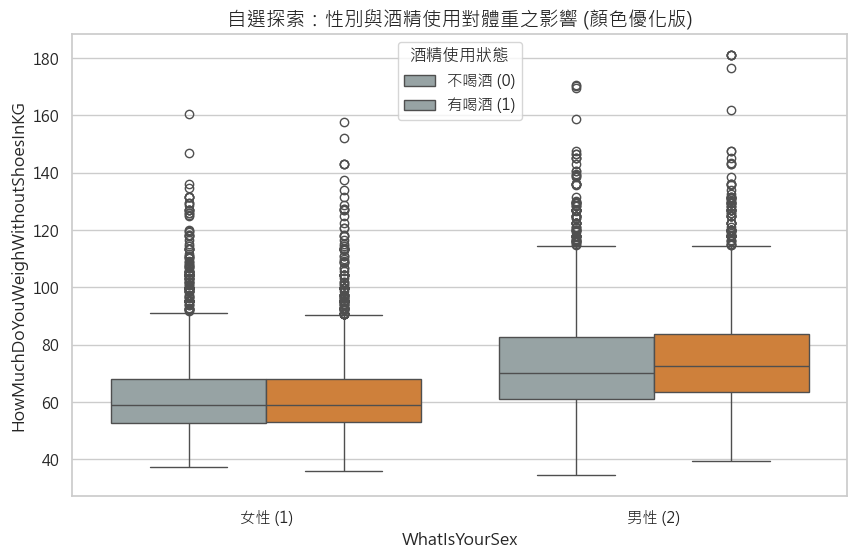

In [37]:
# --- 自選探索：性別與酒精交互統計 ---
gender_col = 'WhatIsYourSex'
weight_col = 'HowMuchDoYouWeighWithoutShoesInKG'

# 確保欄位沒有缺失值
df_sub = df_alc.dropna(subset=[gender_col, weight_col]).copy()

# 1. 計算各組統計指標
for g_val, g_name in {1: "女性 (1)", 2: "男性 (2)"}.items():
    for a_val, a_name in {0: "不喝酒 (0)", 1: "有喝酒 (1)"}.items():
        subset = df_sub[(df_sub[gender_col] == g_val) & (df_sub['alcohol_binary'] == a_val)][weight_col]
        print(f"📍 {g_name} + {a_name}: n={len(subset)}, Mean={subset.mean():.2f}, Median={subset.median():.2f}, SD={subset.std():.2f}")

# 2. 視覺化箱線圖
plt.figure(figsize=(10, 6))
custom_palette = {0: "#95a5a6", 1: "#e67e22"} # 0:灰色, 1:橘色
sns.boxplot(x=gender_col, y=weight_col, hue='alcohol_binary', data=df_sub, palette=custom_palette)
plt.xticks([0, 1], ['女性 (1)', '男性 (2)'])
plt.title('自選探索：性別與酒精使用對體重之影響 (顏色優化版)', fontsize=14)
plt.legend(title='酒精使用狀態', labels=['不喝酒 (0)', '有喝酒 (1)'])
fig_gender_alc = plt.gcf()

In [28]:
# --- 自選探索：性別與酒精交互統計 (命名規則優化版) ---

# 1. 定義變數名稱與對照字典
gender_col = 'WhatIsYourSex'
weight_col = 'HowMuchDoYouWeighWithoutShoesInKG'
alc_col = 'alcohol_binary'

# 定義命名規則 (用於 print 輸出)
gender_labels = {1: "女性 (Female, 編碼 1)", 2: "男性 (Male, 編碼 2)"}
alc_labels = {0: "不喝酒 (No/Failure, 編碼 0)", 1: "有喝酒 (Yes/Success, 編碼 1)"}

# 2. 計算整體缺失狀況
# 只要這三個欄位有一個缺失，該筆樣本就不會進入此項探索
missing_exploration = df_alc[[gender_col, alc_col, weight_col]].isnull().any(axis=1).sum()
print(f"【自選探索資料診斷】")
print(f"有效分析總樣本數: {len(df_sub)}")
print(f"缺失值排除數量: {missing_exploration} 筆\n")

# 3. 循環計算各組統計量
print(f"📋 【各分組條列式統計結果】")
for g_val, g_name in gender_labels.items():
    for a_val, a_name in alc_labels.items():
        # 篩選特定性別與酒精狀態的子群體
        subset = df_sub[(df_sub[gender_col] == g_val) & (df_sub[alc_col] == a_val)][weight_col]
        
        print("-" * 40)
        print(f"📍 群體：{g_name} + {a_name}")
        print(f"  • 樣本規模 (n): {len(subset)} 筆")
        print(f"  • 平均體重 (Mean): {subset.mean():.2f} kg")
        print(f"  • 中位數 (Median): {subset.median():.2f} kg")
        print(f"  • 標準差 (SD): {subset.std():.2f} kg")
        print(f"  • 極值區間: {subset.min():.2f} (Min) ~ {subset.max():.2f} (Max)")
        print(f"  • 四分位數: Q1={subset.quantile(0.25):.2f} / Q3={subset.quantile(0.75):.2f}")

【自選探索資料診斷】
有效分析總樣本數: 11843
缺失值排除數量: 826 筆

📋 【各分組條列式統計結果】
----------------------------------------
📍 群體：女性 (Female, 編碼 1) + 不喝酒 (No/Failure, 編碼 0)
  • 樣本規模 (n): 3268 筆
  • 平均體重 (Mean): 62.39 kg
  • 中位數 (Median): 58.97 kg
  • 標準差 (SD): 14.18 kg
  • 極值區間: 37.20 (Min) ~ 160.57 (Max)
  • 四分位數: Q1=52.62 / Q3=68.04
----------------------------------------
📍 群體：女性 (Female, 編碼 1) + 有喝酒 (Yes/Success, 編碼 1)
  • 樣本規模 (n): 2680 筆
  • 平均體重 (Mean): 62.15 kg
  • 中位數 (Median): 58.97 kg
  • 標準差 (SD): 13.84 kg
  • 極值區間: 35.83 (Min) ~ 157.85 (Max)
  • 四分位數: Q1=53.07 / Q3=68.04
----------------------------------------
📍 群體：男性 (Male, 編碼 2) + 不喝酒 (No/Failure, 編碼 0)
  • 樣本規模 (n): 3181 筆
  • 平均體重 (Mean): 73.70 kg
  • 中位數 (Median): 70.31 kg
  • 標準差 (SD): 17.33 kg
  • 極值區間: 34.47 (Min) ~ 170.55 (Max)
  • 四分位數: Q1=61.24 / Q3=82.56
----------------------------------------
📍 群體：男性 (Male, 編碼 2) + 有喝酒 (Yes/Success, 編碼 1)
  • 樣本規模 (n): 2714 筆
  • 平均體重 (Mean): 75.71 kg
  • 中位數 (Median): 72.58 kg
  • 標準差 (SD): 17.19 kg

自選探索：性別、酒精與體重之交互觀察 (Written Observations)

[數據觀察：分組統計表與箱線圖分析]
01.性別間的顯著差異：
* 男性的體重中位數（約 70.31 - 72.58 kg）明顯高於女性（均為 58.97 kg） 。
* 這證實了性別是影響體重分佈的首要生理因素，在進行後續推論統計時，必須考慮性別帶來的變異 。

02.酒精使用在不同性別下的表現：
* 男性組別：有飲酒習慣者的平均體重（75.71 kg）略高於不喝酒者（73.70 kg），且中位數也有所提升 。
* 女性組別：飲酒者與非飲酒者的體重特徵極為接近，中位數完全一致（均為 58.97 kg），平均數差異亦極小（62.15 kg vs 62.39 kg） 。

03.離群值與分佈特徵：
* 從箱線圖可見 ，所有組別在高端（高體重）均存在大量的離群值，顯示各性別中都有少部分體重極高的個案。
* 採用顏色優化版圖表後 ，可以清晰觀察到男性組別的體重分佈範圍（箱體寬度）比女性更廣，顯示男性的體重變異度較大 。

04.對後續推論之意義：
* 此觀察顯示，酒精與體重的關聯在男性身上似乎比女性更為明顯。這提示我們，雖然全體樣本的平均值重要，但性別差異可能是解釋體重變異的關鍵因子 。

### Extended Exploration: Interaction Analysis of Biological Sex, Alcohol Use, and Weight
**[Data Observation: Grouped Statistics and Boxplot Analysis]**

* **01. Significant Gender Differences**:
    * The median weight for males (approx. 70.31 - 72.58 kg) is significantly higher than that for females (approx. 58.97 kg).
    * This confirms that biological sex is the primary factor influencing weight distribution. When conducting subsequent inferential statistics, gender-related variance must be considered as a critical control variable.
* **02. Alcohol Usage Patterns Across Genders**:
    * **Male Group**: Drinkers show a slightly higher average weight (75.71 kg) compared to non-drinkers (73.70 kg), with a corresponding increase in the median.
    * **Female Group**: Weight characteristics between drinkers and non-drinkers are nearly identical. The medians are exactly the same (58.97 kg), and the difference in means is negligible (62.15 kg vs. 62.39 kg).
* **03. Outliers and Distribution Characteristics**:
    * The boxplots reveal a significant number of high-end outliers in all groups, indicating that a small portion of individuals in every demographic has exceptionally high body weight.
    * The color-optimized charts clearly illustrate that the weight distribution range (interquartile range/box width) is broader for males than for females, suggesting higher variability in male body weight.
* **04. Implications for Subsequent Inference**:
    * These observations suggest that the association between alcohol consumption and weight appears more pronounced in males than in females. This hints that while the overall sample mean is important, "Biological Sex" may act as a key **moderator** in explaining the relationship between alcohol use and weight variation.

In [31]:
import os

# --- 1. 建立所有必要的目錄 ---
os.makedirs('../outputs/tables/', exist_ok=True)
os.makedirs('../outputs/figures/', exist_ok=True)
os.makedirs('../data/processed/', exist_ok=True)

# --- 2. 儲存統計表格 (Tables) ---
summary_table_alc.to_csv('../outputs/tables/02_alcohol_summary.csv')
pd.DataFrame(desc_stats, index=['Value']).T.to_csv('../outputs/tables/02_weight_summary.csv')
print("📊 統計表格已存入：../outputs/tables/")

# --- 3. 儲存視覺化圖表 (Figures) ---
save_fig_path = '../outputs/figures/'
fig_alc_raw.savefig(save_fig_path + '02_alcohol_raw_dist.png', dpi=300, bbox_inches='tight')
fig_alc_bin.savefig(save_fig_path + '02_alcohol_binary_dist.png', dpi=300, bbox_inches='tight')
fig_weight_hist.savefig(save_fig_path + '02_weight_histogram.png', dpi=300, bbox_inches='tight')
fig_weight_box.savefig(save_fig_path + '02_weight_boxplot.png', dpi=300, bbox_inches='tight')
fig_weight_violin.savefig('../outputs/figures/02_weight_violin.png', dpi=300, bbox_inches='tight')
fig_gender_alc.savefig('../outputs/figures/02_gender_alcohol_boxplot.png', dpi=300, bbox_inches='tight')
print(f"🖼️  6張 EDA 圖表已存入：{save_fig_path}")

# --- 4. 儲存最終用於統計推論的資料檔 (Final Data) ---
# 確保這個 df 是已經去掉缺失值、重編碼完成的最終版本
df_alc.to_csv('../data/processed/yrbs_final.csv', index=False, encoding='utf-8-sig')
print("🚀 最終分析資料集已存入：../data/processed/yrbs_final.csv")


📊 統計表格已存入：../outputs/tables/
🖼️  6張 EDA 圖表已存入：../outputs/figures/
🚀 最終分析資料集已存入：../data/processed/yrbs_final.csv
